In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
import tensorflow as tf
from tensorflow.keras import layers, models

**Loading the digits dataset and converting it to a dataframe**

In [2]:
digits = load_digits()
X, y = digits.data, digits.target  
images = digits.images

df = pd.DataFrame(X, columns=[f'pixel_{i}' for i in range(X.shape[1])])
df['target'] = y

**Exploratory Data Analysis**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pixel_0   1797 non-null   float64
 1   pixel_1   1797 non-null   float64
 2   pixel_2   1797 non-null   float64
 3   pixel_3   1797 non-null   float64
 4   pixel_4   1797 non-null   float64
 5   pixel_5   1797 non-null   float64
 6   pixel_6   1797 non-null   float64
 7   pixel_7   1797 non-null   float64
 8   pixel_8   1797 non-null   float64
 9   pixel_9   1797 non-null   float64
 10  pixel_10  1797 non-null   float64
 11  pixel_11  1797 non-null   float64
 12  pixel_12  1797 non-null   float64
 13  pixel_13  1797 non-null   float64
 14  pixel_14  1797 non-null   float64
 15  pixel_15  1797 non-null   float64
 16  pixel_16  1797 non-null   float64
 17  pixel_17  1797 non-null   float64
 18  pixel_18  1797 non-null   float64
 19  pixel_19  1797 non-null   float64
 20  pixel_20  1797 non-null   floa

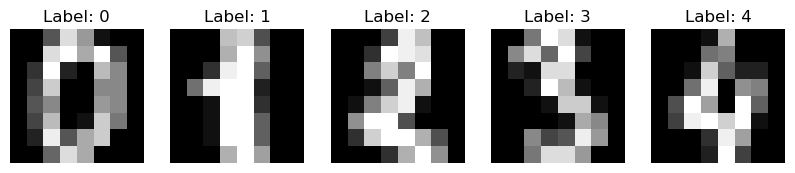

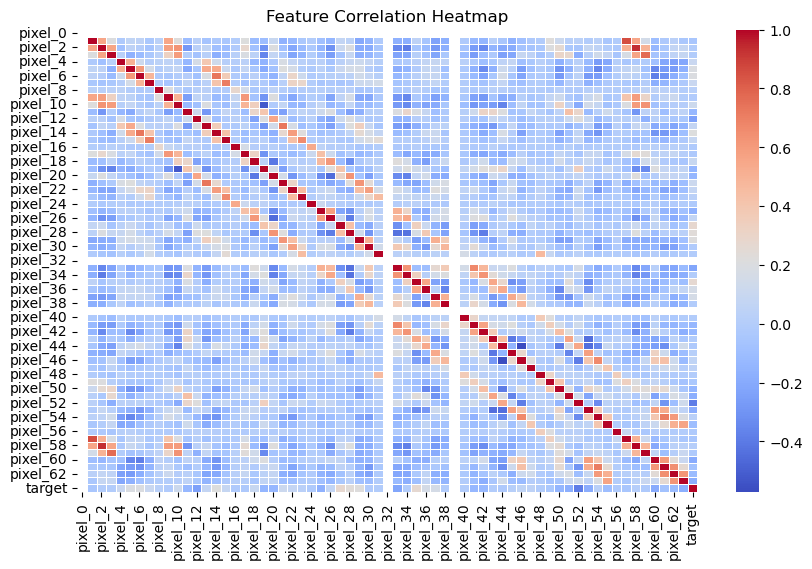

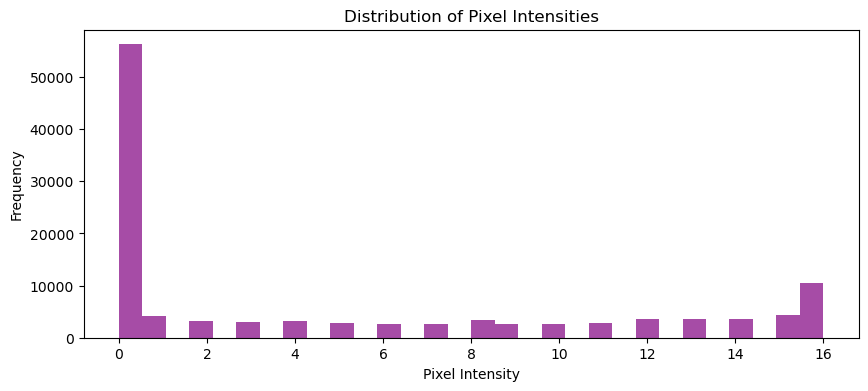

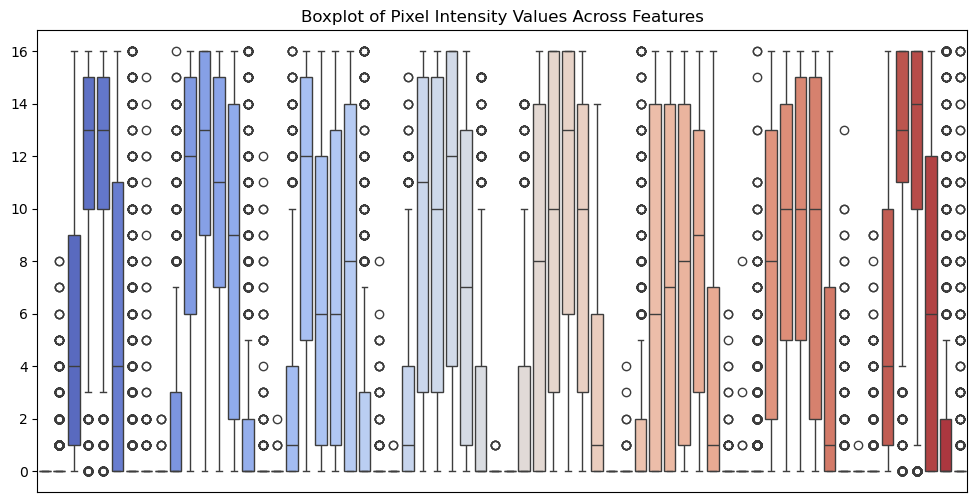

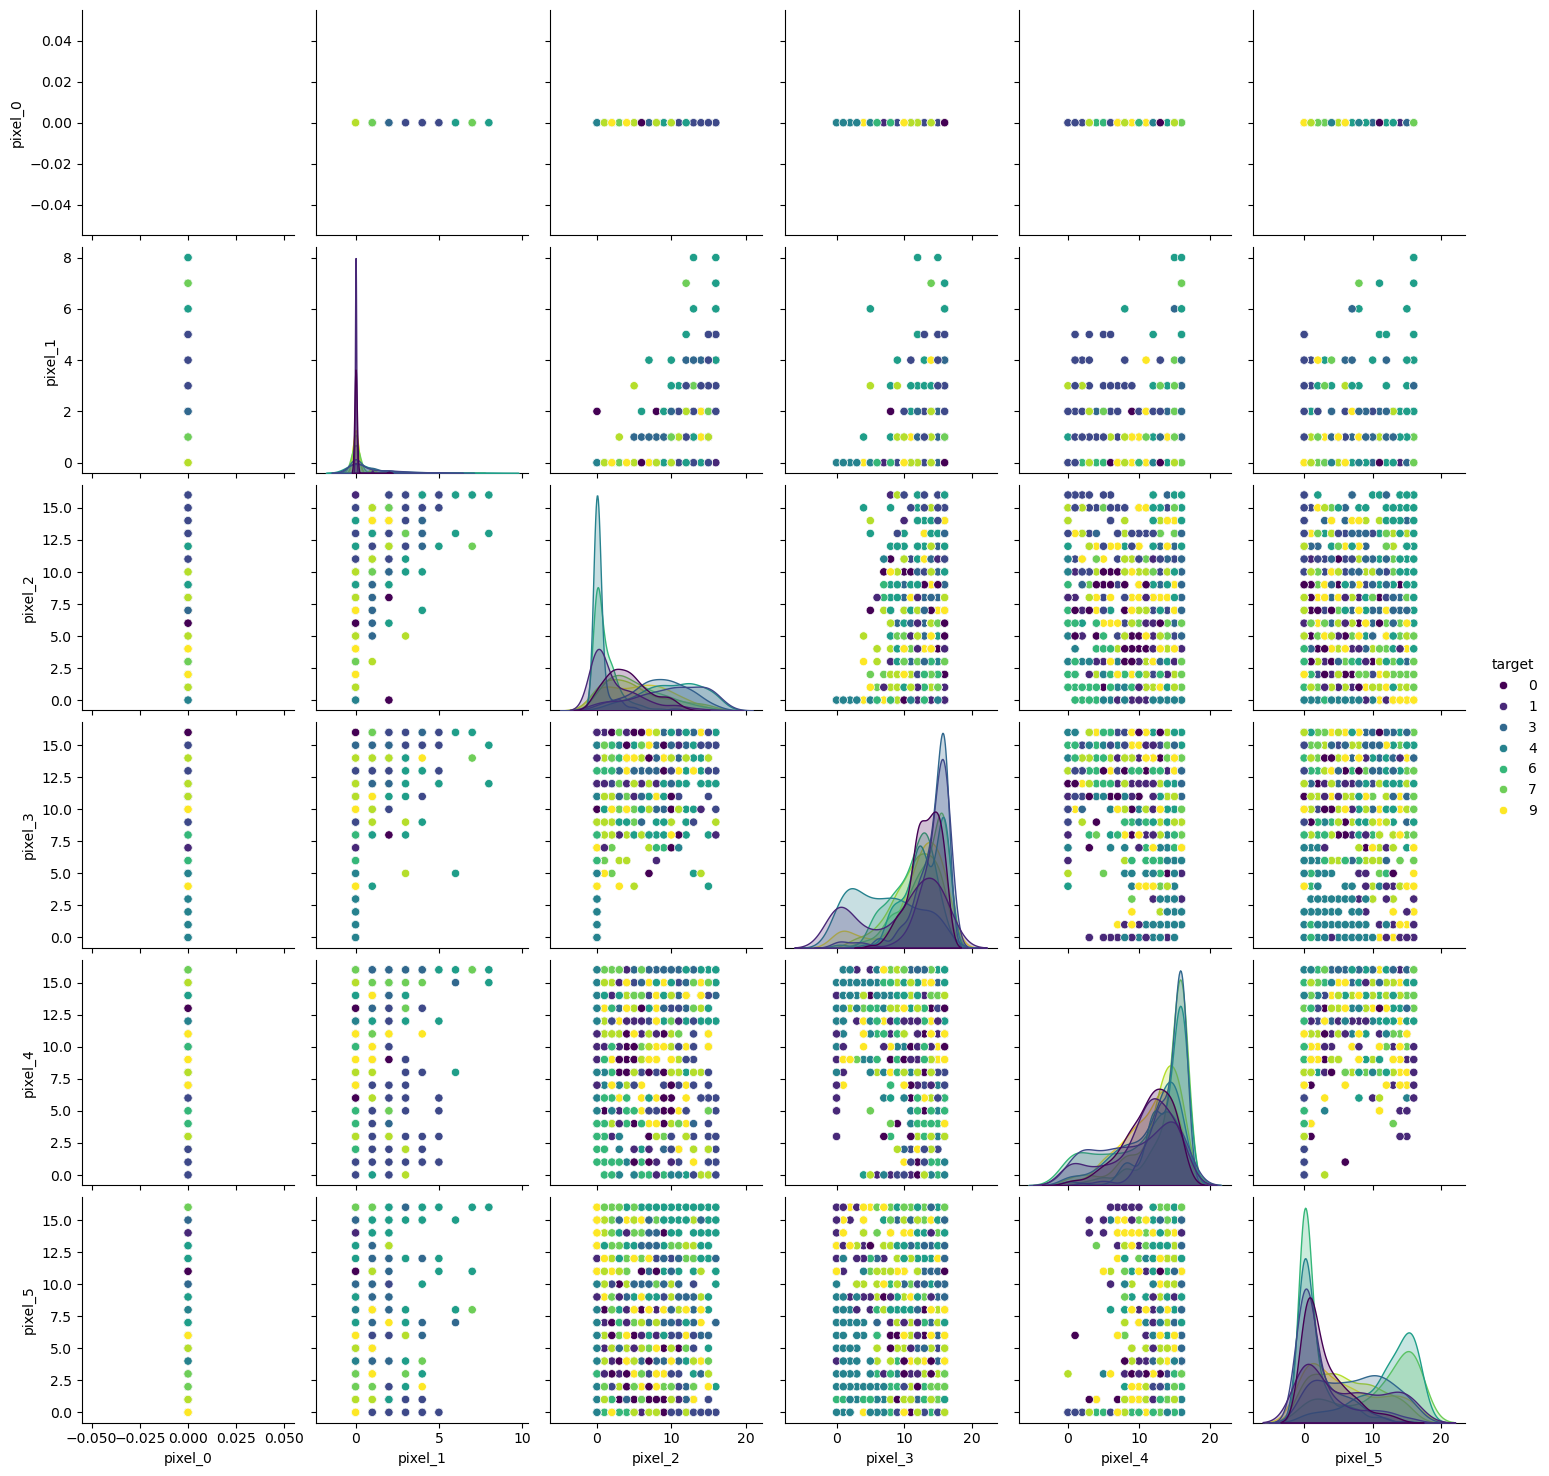

In [3]:
print(df.info())
print(df.describe())
print("Class Distribution:\n", df['target'].value_counts())

# Visualizing some of the Images
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Distribution of Pixel Intensities
plt.figure(figsize=(10, 4))
plt.hist(X.flatten(), bins=30, color='purple', alpha=0.7)
plt.title("Distribution of Pixel Intensities")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

# Boxplot of pixel intensity values
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.iloc[:, :-1], palette='coolwarm')
plt.xticks([])
plt.title("Boxplot of Pixel Intensity Values Across Features")
plt.show()

# Pairplot for First Few Features and Target
sns.pairplot(df.iloc[:, :6].join(df['target']), hue='target', palette='viridis')
plt.show()


**Train-Test split and Data Standardization**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardization only for SVM since it is sensitive to feature scaling.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Modeling - SVM model**

In [5]:
#Training the Support Vector Machine (SVM) model with an Radial Basis Function kernel.
print("\nTraining SVM Model...")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
print("\nSVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report (SVM):\n", classification_report(y_test, y_pred_svm))



Training SVM Model...

SVM Accuracy: 0.975

Classification Report (SVM):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      0.97      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       0.97      1.00      0.99        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        36
           8       1.00      0.91      0.96        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360



**Evaluation - SVM model**

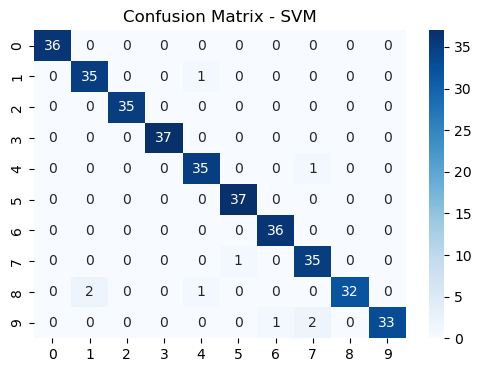

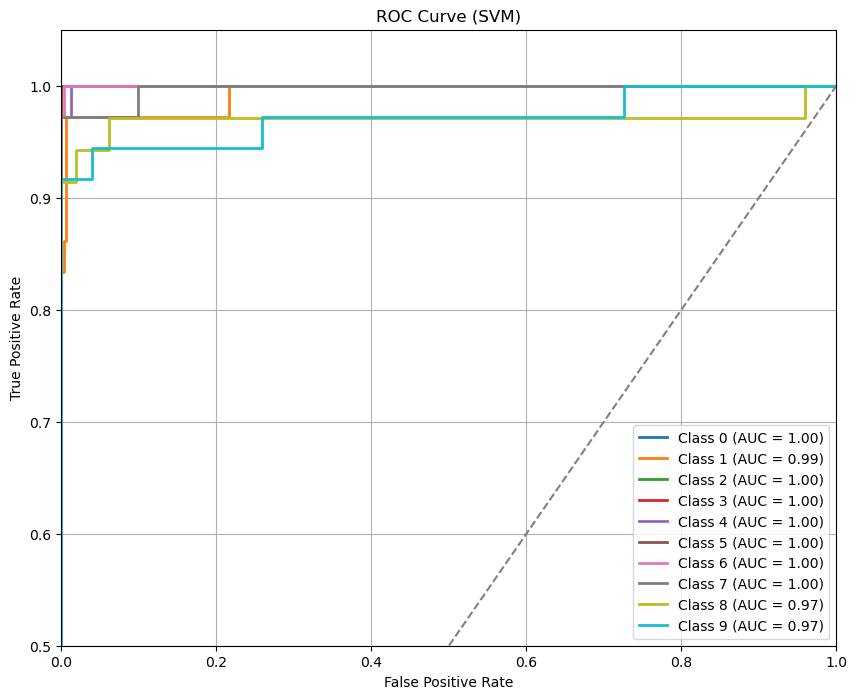

In [17]:
# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.show()

# Binarize the test labels for multi-class ROC plotting
y_test_binarized = label_binarize(y_test, classes=range(10))
y_score = svm_model.decision_function(X_test_scaled)

# Plotting ROC curves for each class
plt.figure(figsize=(10, 8))
for i in range(10):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Diagonal line for reference 
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# Setting consistent axis limits for better comparison
plt.xlim([0.0, 1.0])
plt.ylim([0.5, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (SVM)")
plt.legend(loc="lower right")
plt.grid()
plt.show()

**Modeling - CNN model**

In [18]:
# Normalizing and reshaping the images for CNN (grayscale, 8x8)
X_cnn = images / 16.0
X_cnn = X_cnn.reshape(-1, 8, 8, 1)

# Splitting the data while keeping the class distribution intact
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y, test_size=0.2, random_state=42, stratify=y
)

# Building a basic CNN model
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(8, 8, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compiling and training the model with Adam optimizer
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("\nTraining CNN Model...")
cnn_model.fit(X_train_cnn, y_train_cnn, epochs=10, validation_data=(X_test_cnn, y_test_cnn))



Training CNN Model...
Epoch 1/10


C:\Users\krish\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3092 - loss: 2.2226 - val_accuracy: 0.7750 - val_loss: 1.7891
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8354 - loss: 1.5462 - val_accuracy: 0.8917 - val_loss: 0.8217
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8955 - loss: 0.6817 - val_accuracy: 0.9139 - val_loss: 0.4185
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9345 - loss: 0.3607 - val_accuracy: 0.9167 - val_loss: 0.2939
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9418 - loss: 0.2579 - val_accuracy: 0.9444 - val_loss: 0.2176
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9466 - loss: 0.2193 - val_accuracy: 0.9528 - val_loss: 0.1871
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9646 - loss: 0.1675 - val_accuracy: 0.9472 - val_loss: 0.1682
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9615 - loss: 0.1572 - val_accuracy: 0.9556 - val_loss: 0.1387
Epo

**Evaluation - CNN model**

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9654 - loss: 0.1298 

CNN Accuracy: 0.9778


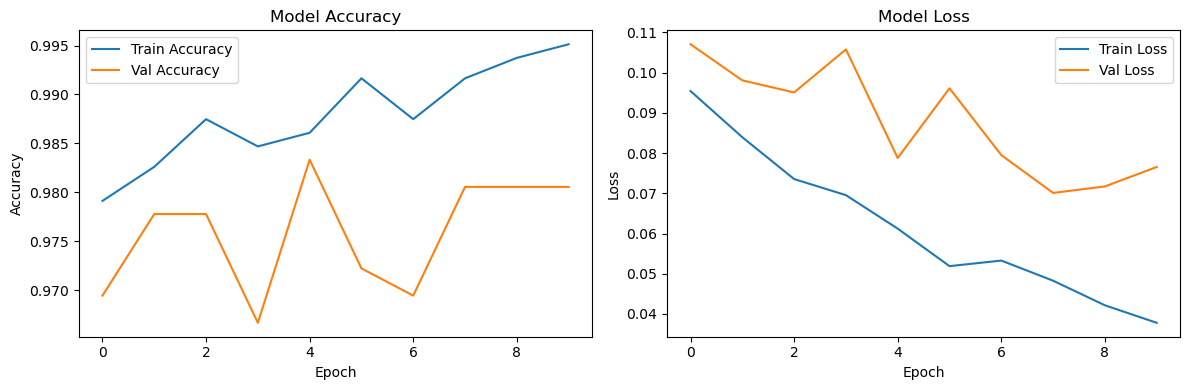

In [19]:
# Evaluating the CNN on the test set
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_cnn)
print(f"\nCNN Accuracy: {cnn_acc:.4f}")

# Training again to store the history for plotting (quiet mode)
history = cnn_model.fit(X_train_cnn, y_train_cnn, epochs=10, validation_data=(X_test_cnn, y_test_cnn), verbose=0)

# Plotting accuracy and loss over epochs
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# # Plotting the training and validation loss to see how the model is learning
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()